In [1]:
import pandas

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/02_elja_idr/tmp.step3.a.bed'
output_dir = '/Users/adrian/research/bmcbf/004_keilir/results/03_necio_viz/'

In [4]:
df = pandas.read_csv(input_file, sep='\t', header=None)
df

,0,1,2,3,4,5,6,7,8
0,chr1,906047,906957,4.36905,5.68956,12.04380,26.0341,8.86998,22.2288
1,chr1,910547,911658,5.02003,5.14881,15.09840,39.7947,13.64870,35.4346
2,chr1,913227,914687,5.25954,5.2071,8.65649,15.6048,6.95871,11.7546
3,chr1,921533,924119,4.66193,4.19049,10.24550,20.7625,8.98299,20.4170
4,chr1,936850,940044,4.30951,4.16968,12.78370,32.2862,9.12995,30.7373
...,...,...,...,...,...,...,...,...,...
24754,chr17_GL000205v2_random,77948,79211,5.32684,10.0309,9.01226,21.7646,10.62860,25.0595
24755,chrUn_GL000216v2,141556,142105,6.516,10.5948,15.43110,37.5657,9.95611,26.9133
24756,chrUn_GL000216v2,154200,154810,10.7572,20.2711,15.80750,38.9105,19.89320,55.2131
24757,chrUn_GL000216v2,173451,174114,15.1738,41.2001,18.00050,56.3830,15.36460,41.2392


In [5]:
bad_mask = pandas.to_numeric(df[3], errors="coerce").isna()
errors = df.loc[bad_mask, 3:6]
print(errors.shape)
errors

(266, 4)


,3,4,5,6
61,.,.,8.65649,15.60480
63,.,.,7.52738,12.43940
91,.,.,6.02190,8.83180
94,.,.,7.90375,13.47770
179,.,.,7.52738,12.43940
...,...,...,...,...
24609,.,.,8.98501,17.12020
24633,.,.,8.28012,14.53620
24678,.,.,4.89280,6.25296
24701,.,.,7.90375,13.47770


In [6]:
cols = list(range(1, 9))

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda col: col.str.strip())
    .replace(".", pandas.NA)
    .apply(lambda col: pandas.to_numeric(col, errors="coerce"))
)
df.dtypes

0     object
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
dtype: object

In [7]:
df

,0,1,2,3,4,5,6,7,8
0,chr1,906047,906957,4.36905,5.68956,12.04380,26.0341,8.86998,22.2288
1,chr1,910547,911658,5.02003,5.14881,15.09840,39.7947,13.64870,35.4346
2,chr1,913227,914687,5.25954,5.20710,8.65649,15.6048,6.95871,11.7546
3,chr1,921533,924119,4.66193,4.19049,10.24550,20.7625,8.98299,20.4170
4,chr1,936850,940044,4.30951,4.16968,12.78370,32.2862,9.12995,30.7373
...,...,...,...,...,...,...,...,...,...
24754,chr17_GL000205v2_random,77948,79211,5.32684,10.03090,9.01226,21.7646,10.62860,25.0595
24755,chrUn_GL000216v2,141556,142105,6.51600,10.59480,15.43110,37.5657,9.95611,26.9133
24756,chrUn_GL000216v2,154200,154810,10.75720,20.27110,15.80750,38.9105,19.89320,55.2131
24757,chrUn_GL000216v2,173451,174114,15.17380,41.20010,18.00050,56.3830,15.36460,41.2392


In [8]:
df['signal'] = df.iloc[:, [3, 5, 7]].mean(axis=1)
df['Q'] = df.iloc[:, [4, 6, 8]].mean(axis=1)
df

,0,1,2,3,4,5,6,7,8,signal,Q
0,chr1,906047,906957,4.36905,5.68956,12.04380,26.0341,8.86998,22.2288,8.427610,17.984153
1,chr1,910547,911658,5.02003,5.14881,15.09840,39.7947,13.64870,35.4346,11.255710,26.792703
2,chr1,913227,914687,5.25954,5.20710,8.65649,15.6048,6.95871,11.7546,6.958247,10.855500
3,chr1,921533,924119,4.66193,4.19049,10.24550,20.7625,8.98299,20.4170,7.963473,15.123330
4,chr1,936850,940044,4.30951,4.16968,12.78370,32.2862,9.12995,30.7373,8.741053,22.397727
...,...,...,...,...,...,...,...,...,...,...,...
24754,chr17_GL000205v2_random,77948,79211,5.32684,10.03090,9.01226,21.7646,10.62860,25.0595,8.322567,18.951667
24755,chrUn_GL000216v2,141556,142105,6.51600,10.59480,15.43110,37.5657,9.95611,26.9133,10.634403,25.024600
24756,chrUn_GL000216v2,154200,154810,10.75720,20.27110,15.80750,38.9105,19.89320,55.2131,15.485967,38.131567
24757,chrUn_GL000216v2,173451,174114,15.17380,41.20010,18.00050,56.3830,15.36460,41.2392,16.179633,46.274100


(4571, 11) purple
(19354, 11) orange
(790, 11) yellow
(44, 11) black


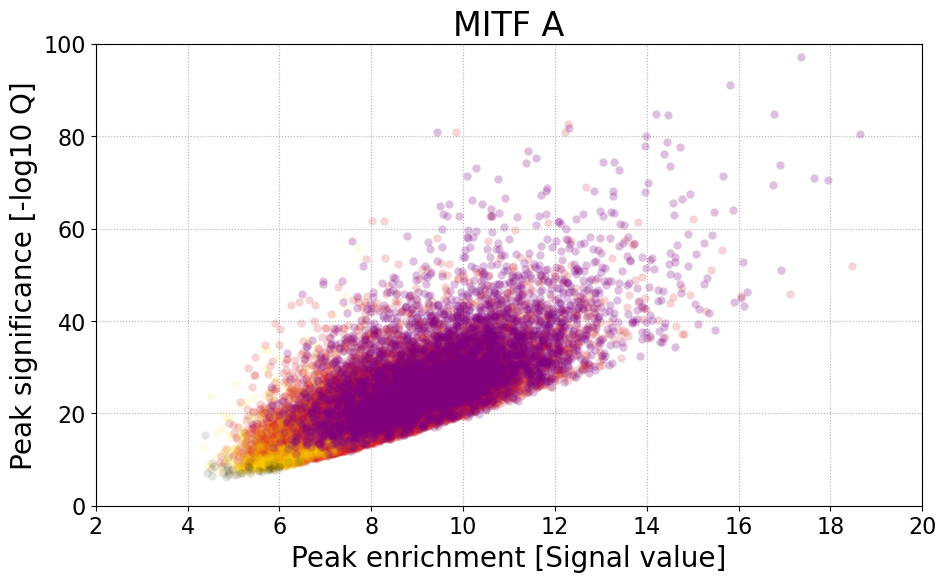

In [9]:
signal_threshold = 5         # encode signal
significance_threshold = 10  # encode significance threshold

# Boolean flags: does replicate i pass both thresholds?
pass_r1 = (df[3] >= signal_threshold) & (df[4] >= significance_threshold)
pass_r2 = (df[5] >= signal_threshold) & (df[6] >= significance_threshold)
pass_r3 = (df[7] >= signal_threshold) & (df[8] >= significance_threshold)

# Count how many replicates pass per row
pass_count = (pandas.concat([pass_r1, pass_r2, pass_r3], axis=1).sum(axis=1))

# arrange
df_black  = df.loc[pass_count == 0].copy()  # none pass
df_yellow = df.loc[pass_count == 1].copy()  # exactly one passes
df_orange = df.loc[pass_count == 2].copy()  # exactly two pass
df_red    = df.loc[pass_count == 3].copy()  # all three pass

print(df_red.shape, 'purple')
print(df_orange.shape, 'orange')
print(df_yellow.shape, 'yellow')
print(df_black.shape, 'black')

# plot
matplotlib.pyplot.plot(df_orange['signal'], df_orange['Q'], 'o', color='tab:red', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_yellow['signal'], df_yellow['Q'], 'o', color='gold', alpha=0.1, mec='none')
matplotlib.pyplot.plot(df_red['signal'], df_red['Q'], 'o', color='purple', alpha=0.25, mec='none')
matplotlib.pyplot.plot(df_black['signal'], df_black['Q'], 'o', color='black', alpha=0.1, mec='none')

matplotlib.pyplot.xlabel('Peak enrichment [Signal value]')
matplotlib.pyplot.ylabel('Peak significance [-log10 Q]')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.xlim(2, 20)
matplotlib.pyplot.ylim(0, 100)

matplotlib.pyplot.title('MITF A')

matplotlib.pyplot.show()

In [10]:
print(df_red.shape)
df_red.to_csv(output_dir+'purple.a.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'orange.a.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange, df_yellow], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'gold.a.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange, df_yellow, df_black], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'black.a.bed', header=False, index=False, sep='\t')

(4571, 11)
(23925, 11)
(24715, 11)
(24759, 11)
